In [1]:
# test new rule of thumb? e.g. const sigmaD
# optimize sigmaS and sigmaD per snapshot for rank 10, 20, 30, 50, 100

In [2]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement  # make_rand_data_rw
import numpy as np
from smooth_POD_ROM.post_processing import get_sigma
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
from matplotlib.ticker import FormatStrFormatter
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [4]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 10,
    "n_val": 900,  # n_x * (n_train-1)/n_train
    "g": saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
}

In [5]:
del case["n_test"]
RAND = False
# if RAND:
#     make_data = make_rand_data_rw  # make_data_rw, make_rand_data_rw
# else:
#     make_data = make_data_rw

In [6]:
nsD = 50
nsS = 30
sigma_S = np.empty((5, 10, nsS, nsD))
sigma_D = np.empty((5, 10, nsS, nsD))
ranks = np.empty((5, 10, nsS, nsD))
mus = np.empty((5, 10, nsS, nsD))
errors = np.empty((5, 10, nsS, nsD))/0

C:\Users\florianma\AppData\Local\Temp\ipykernel_31420\4061573249.py:7: RuntimeWarning: divide by zero encountered in divide
  errors = np.empty((5, 10, nsS, nsD))/0
C:\Users\florianma\AppData\Local\Temp\ipykernel_31420\4061573249.py:7: RuntimeWarning: invalid value encountered in divide
  errors = np.empty((5, 10, nsS, nsD))/0


[[0. ]
 [0.1]
 [0.2]
 [0.3]
 [0.4]
 [0.5]
 [0.6]
 [0.7]
 [0.8]
 [0.9]] [[0.1 ]
 [0.11]
 [0.12]
 [0.13]
 [0.14]
 [0.15]
 [0.16]
 [0.17]
 [0.18]
 [0.19]]


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


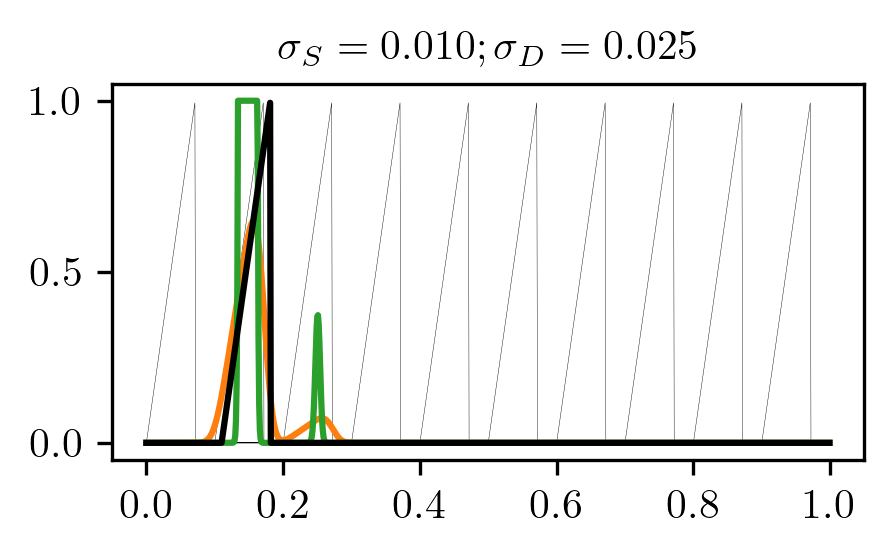

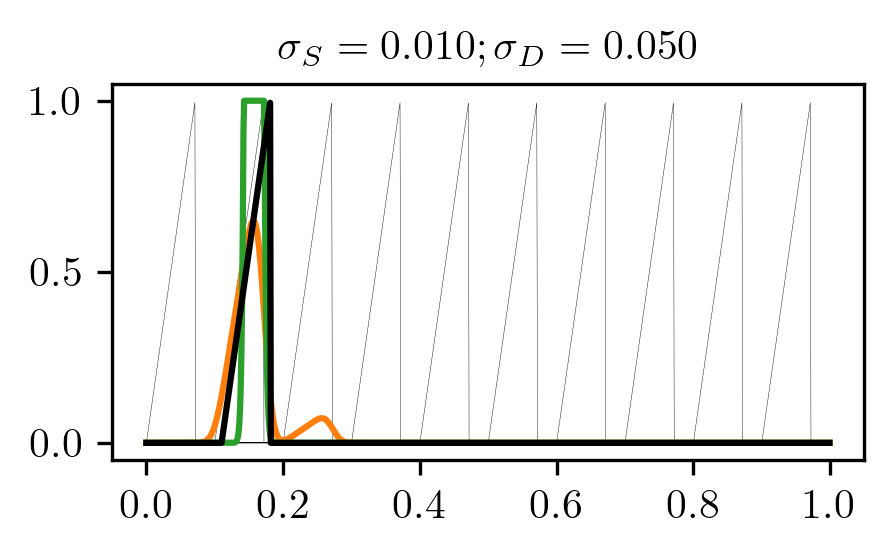

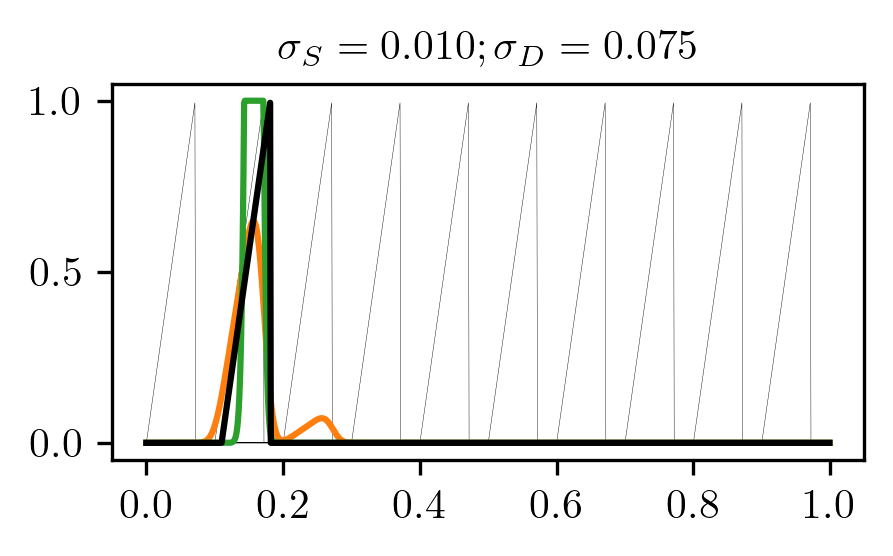

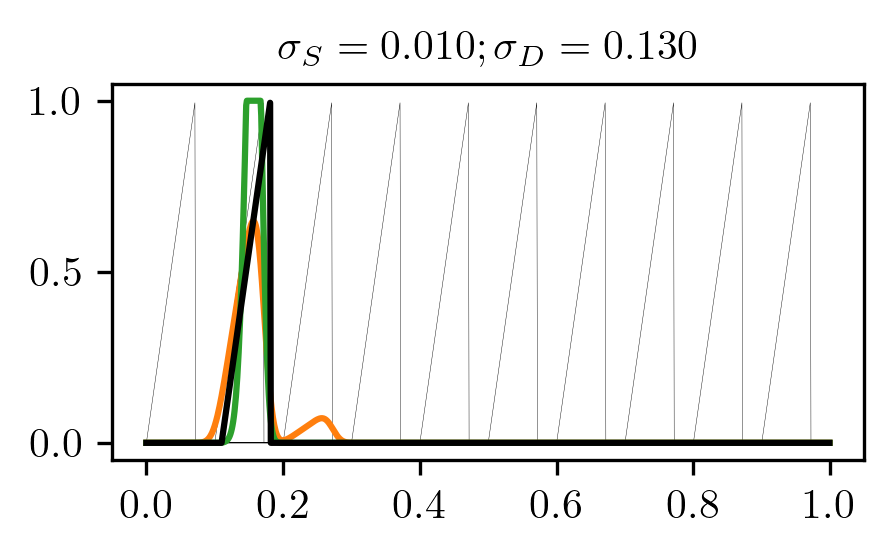

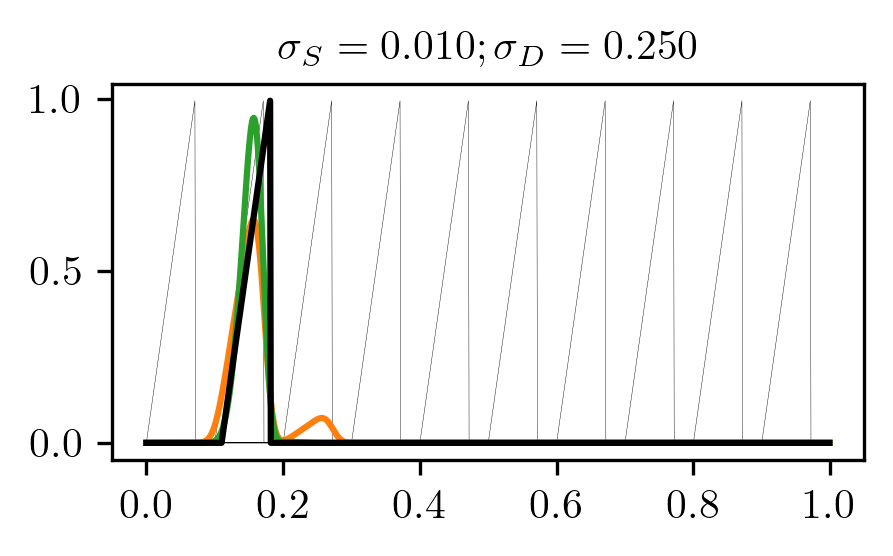

----------------------------------------------------------------------------------------------------------------------


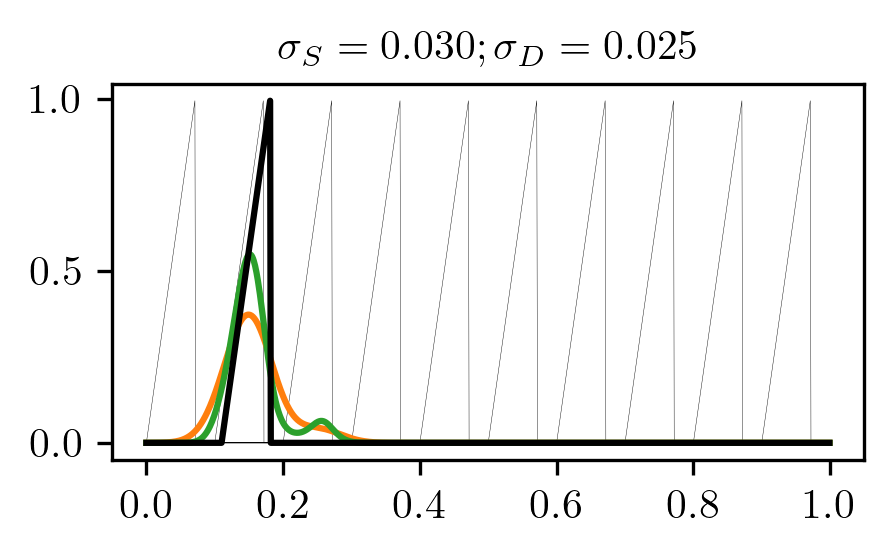

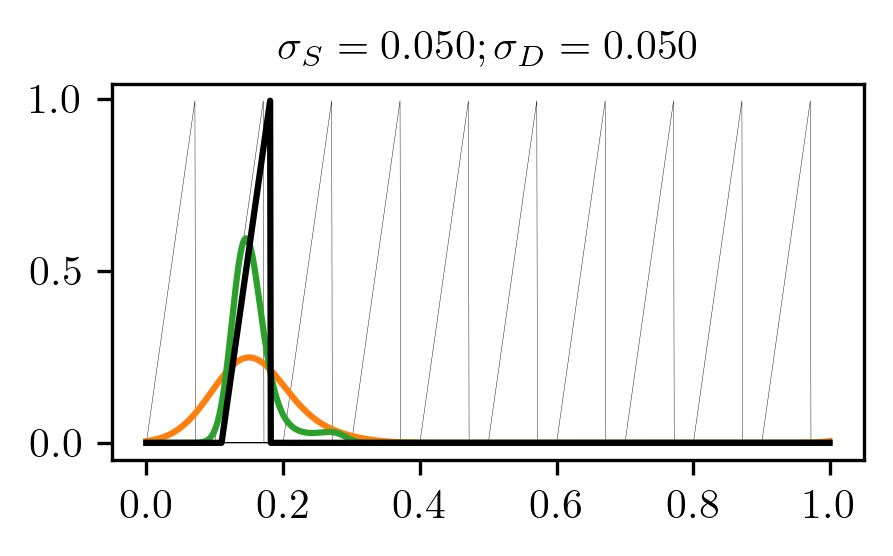

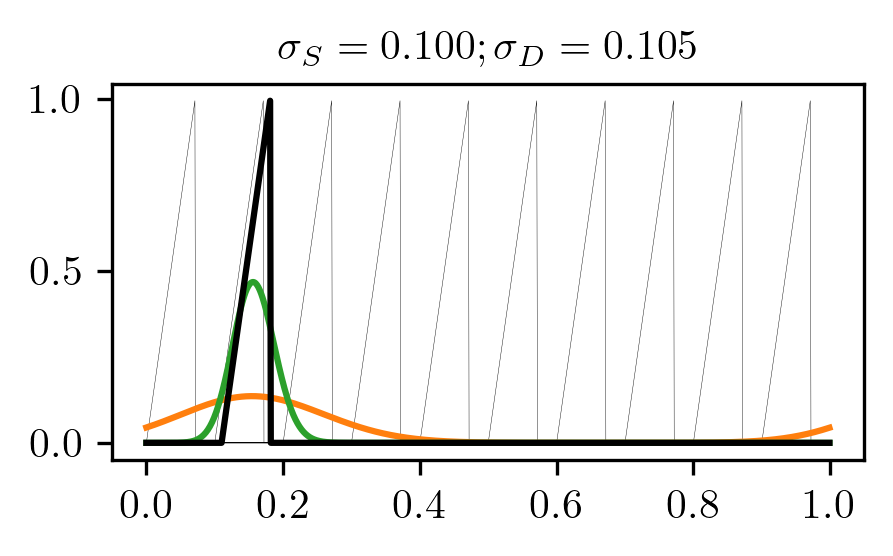

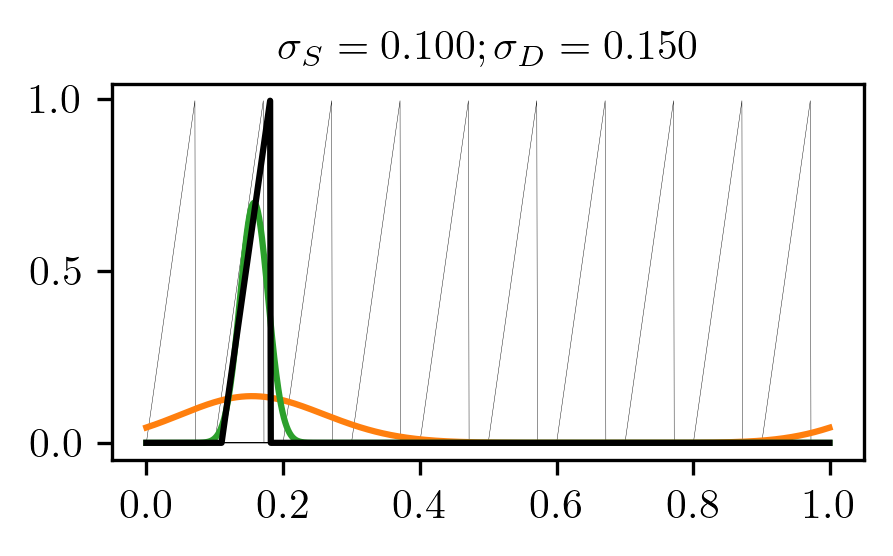

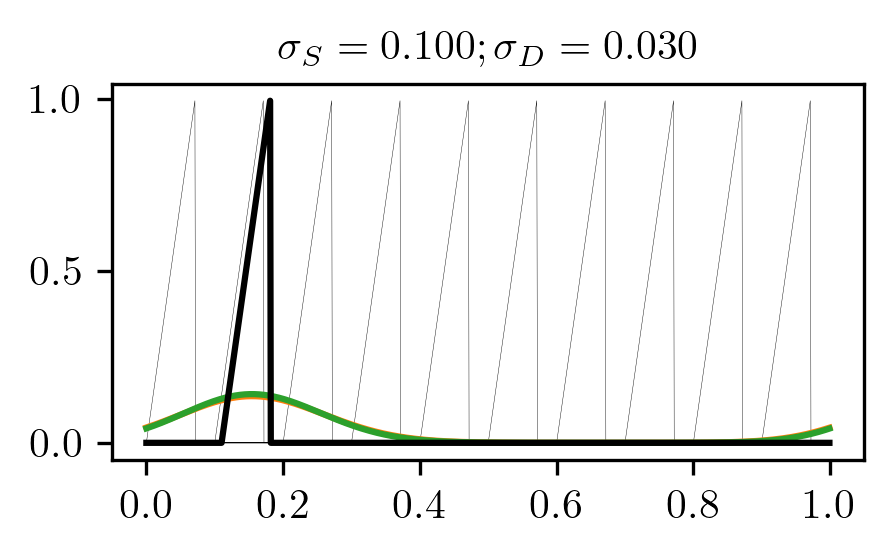

In [7]:
i = 0; rank = 10

case["rank"] = rank
case["n_train"] = rank
case["n_test"] = 10
sigma_opt = 1 / (rank * 2)

sSs = np.linspace(sigma_opt*0.1, sigma_opt*3, nsS)
sDs = np.linspace(sigma_opt*0.1, sigma_opt*5, nsD)
xx, yy = np.meshgrid(sSs, sDs, indexing="ij")

mu_min, mu_max = np.array([0]), np.array([1])
mu_train = np.linspace(mu_min, mu_max, case["n_train"], endpoint=False)
mu_min, mu_max = mu_train[1], mu_train[2]
mu_test = np.linspace(mu_min, mu_max, case["n_test"], endpoint=False)

j = 1; mu = mu_test[j]
sgm_S = 0.01
case["sigma"] = sgm_S
mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
if RAND:
    mu_test, X_test, X_test_s = make_rand_data_rw(np.min(mu_train), np.max(mu_train), n_samples=10, **case)
else:
    mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=10, **case)
my_sROM = train_ROM_rw(mu_train, X_train_s)
print(mu_train, mu_test)
for sgm_D in [0.025, 0.05, 0.075, 0.13, 0.25]:
    case["sigmaD"] = [sgm_D]
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, np.array([mu]), **case)

    for i in range(len(X_train)):
        plt.plot(x, X_train[i], "k-", lw=.1)
    plt.plot(x, X_test_sROM[0], "C1")
    plt.plot(x, X_test_sROMs[0], "C2")
    plt.plot(x, X_test[j], "k-")
    sS_str = "{:.3f}".format(sgm_S)
    sD_str = "{:.3f}".format(sgm_D)
    plt.title(r"$\sigma_S="+sS_str+r"; \sigma_D="+sD_str+"$")
    plt.show()
print("----------------------------------------------------------------------------------------------------------------------")
for sgm_S, sgm_D in zip([0.03, 0.05, 0.1, 0.1, 0.1], [0.025, 0.05, 0.105, 0.15, 0.03]):
    case["sigma"] = sgm_S
    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    if RAND:
        mu_test, X_test, X_test_s = make_rand_data_rw(np.min(mu_train), np.max(mu_train), n_samples=10, **case)
    else:
        mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=10, **case)
    my_sROM = train_ROM_rw(mu_train, X_train_s)

    case["sigmaD"] = [sgm_D]
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, np.array([mu]), **case)
    
    for i in range(len(X_train)):
        plt.plot(x, X_train[i], "k-", lw=.1)
    plt.plot(x, X_test_sROM[0], "C1")
    plt.plot(x, X_test_sROMs[0], "C2")
    plt.plot(x, X_test[j], "k-")
    sS_str = "{:.3f}".format(sgm_S)
    sD_str = "{:.3f}".format(sgm_D)
    plt.title(r"$\sigma_S="+sS_str+r"; \sigma_D="+sD_str+"$")
    plt.show()

0.005000000000000001 0.15000000000000002


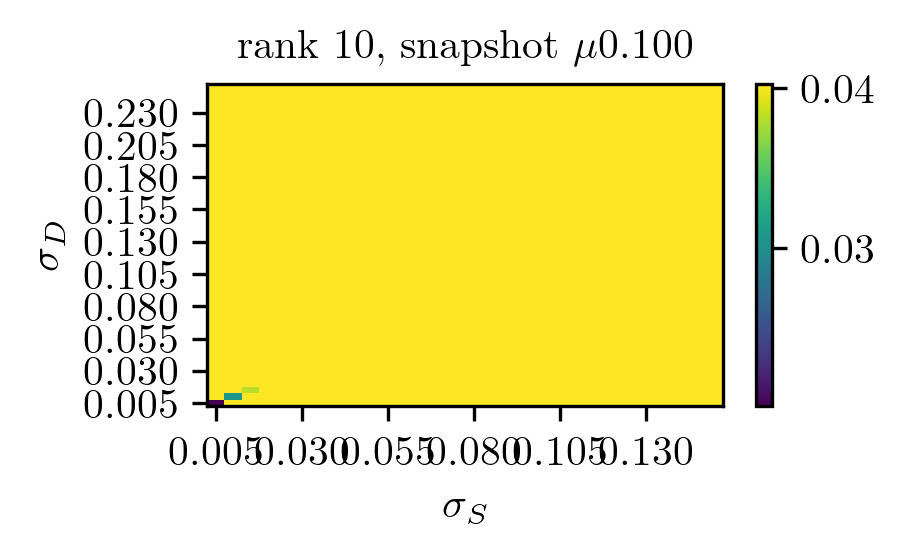

0.005000000000000001 0.15000000000000002


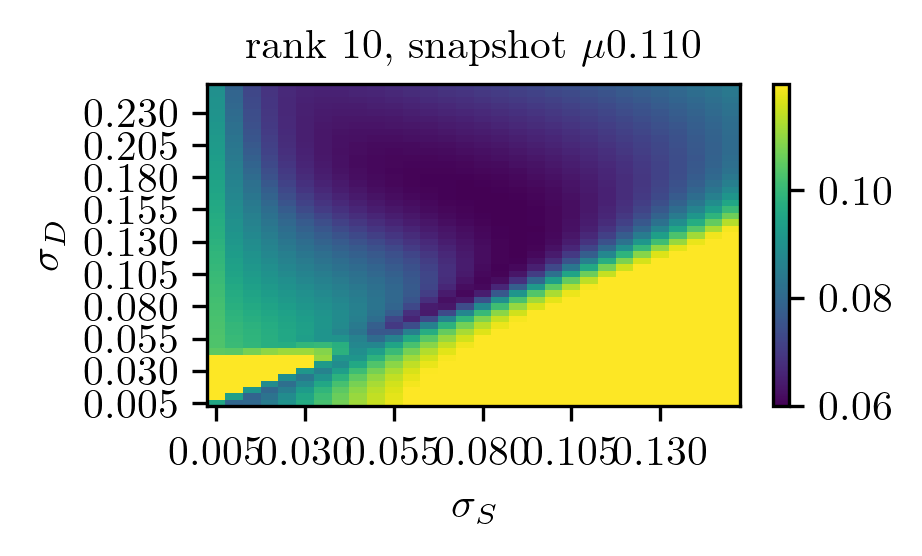

0.005000000000000001 0.15000000000000002


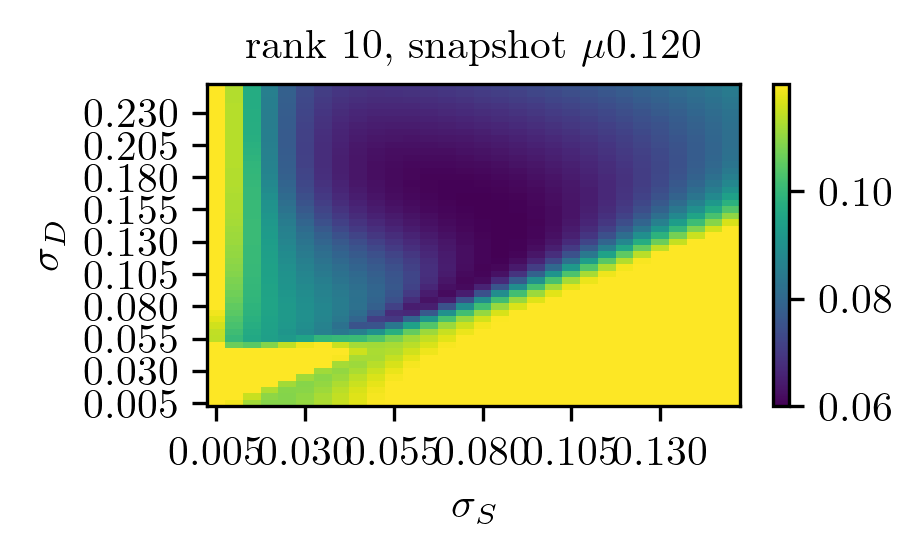

0.005000000000000001 0.15000000000000002


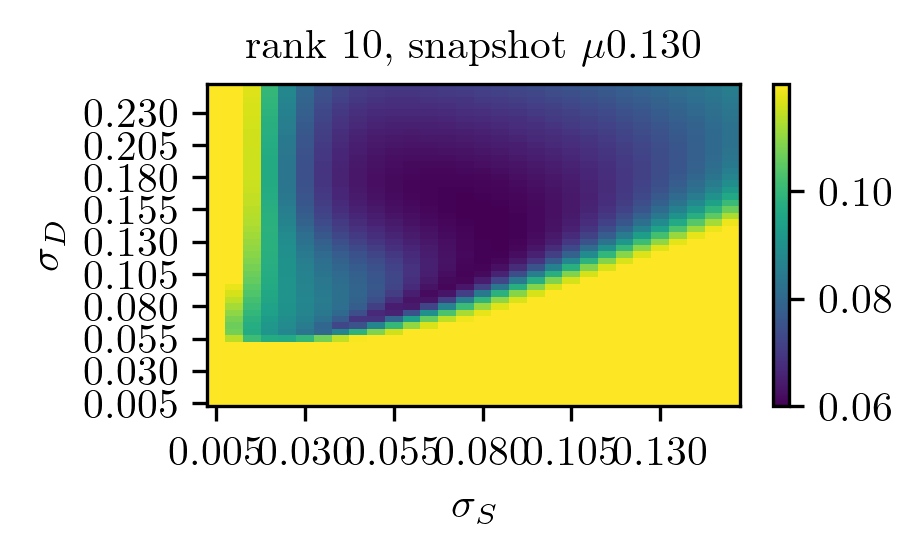

0.005000000000000001 0.15000000000000002


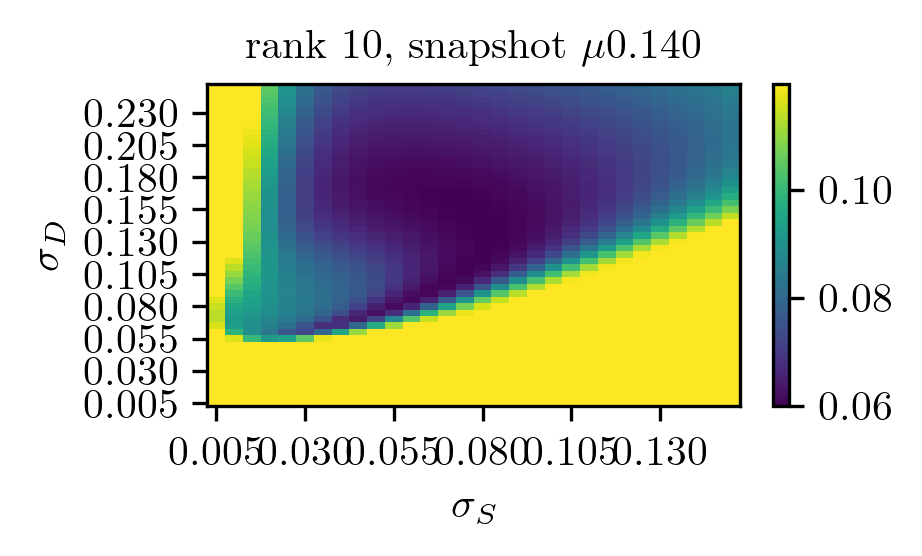

0.005000000000000001 0.15000000000000002


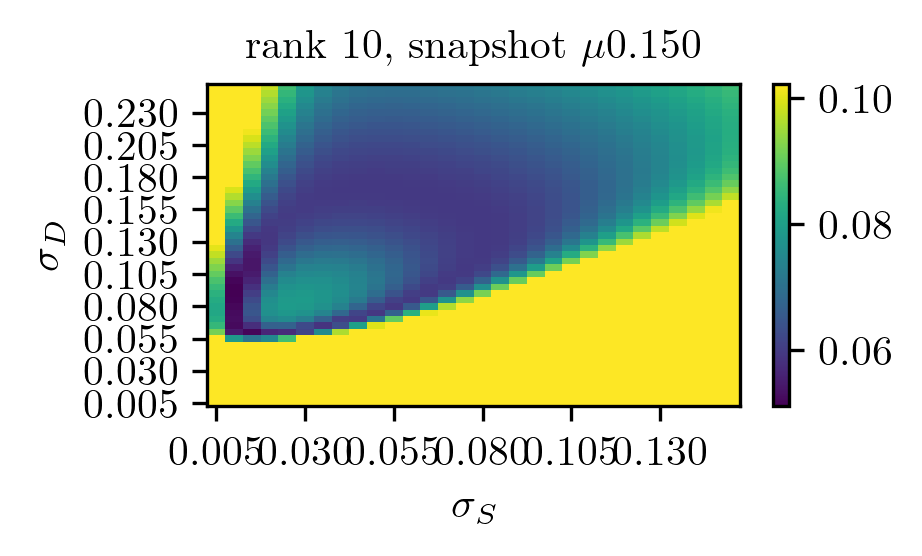

0.005000000000000001 0.15000000000000002


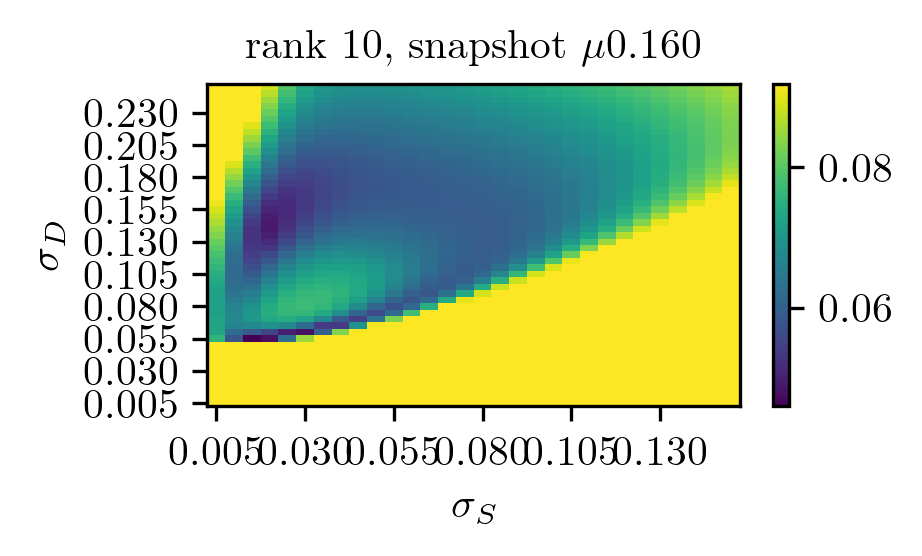

0.005000000000000001 0.15000000000000002


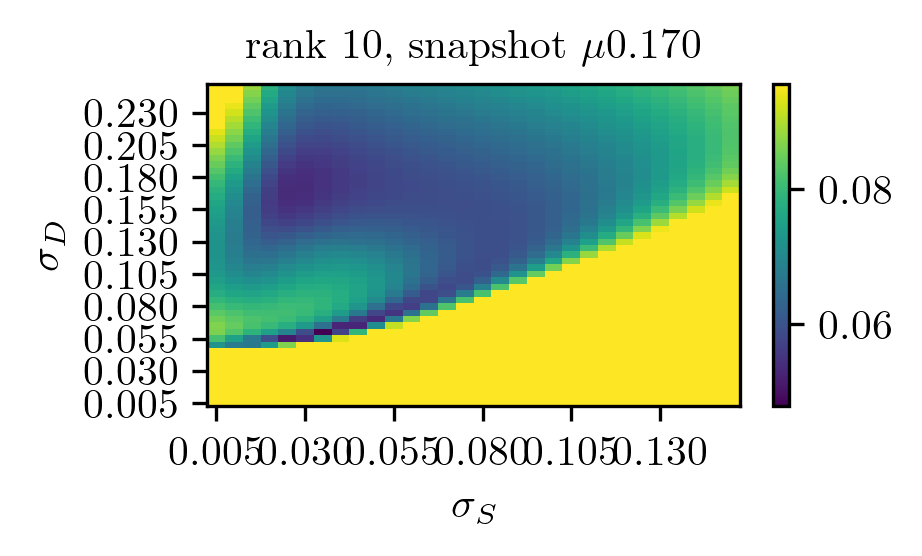

0.005000000000000001 0.15000000000000002


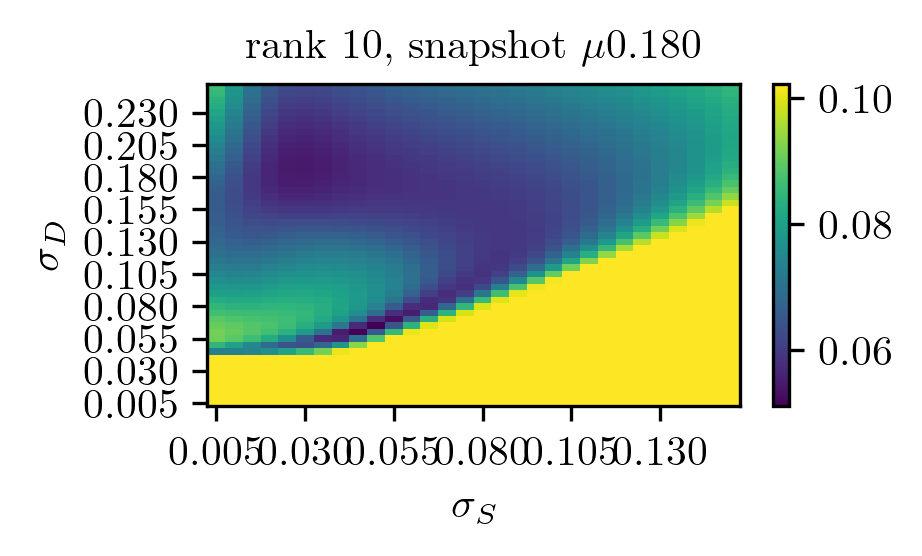

0.005000000000000001 0.15000000000000002


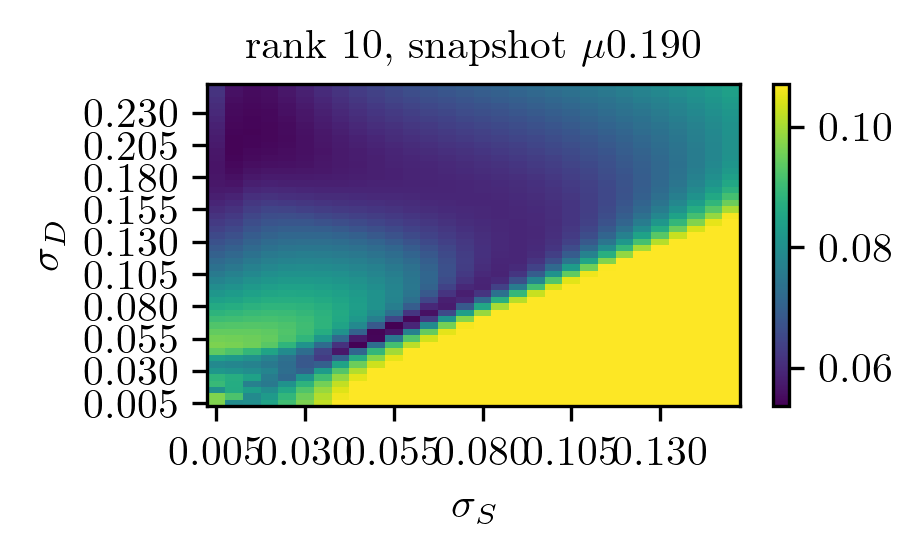

0.0025000000000000005 0.07500000000000001


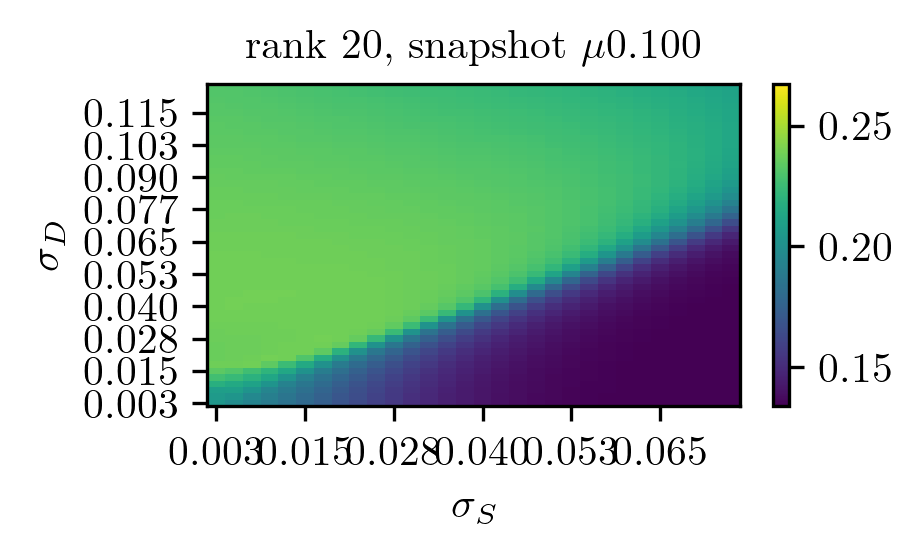

0.0025000000000000005 0.07500000000000001


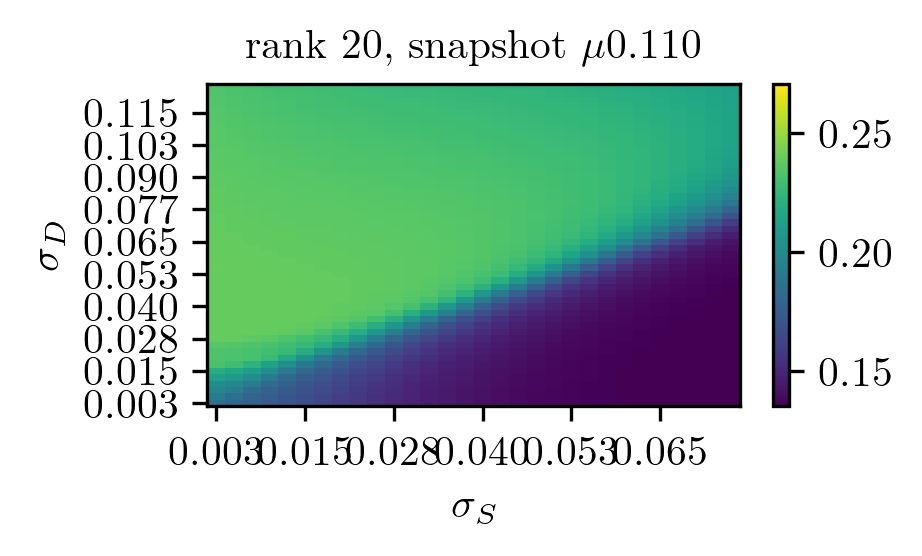

0.0025000000000000005 0.07500000000000001


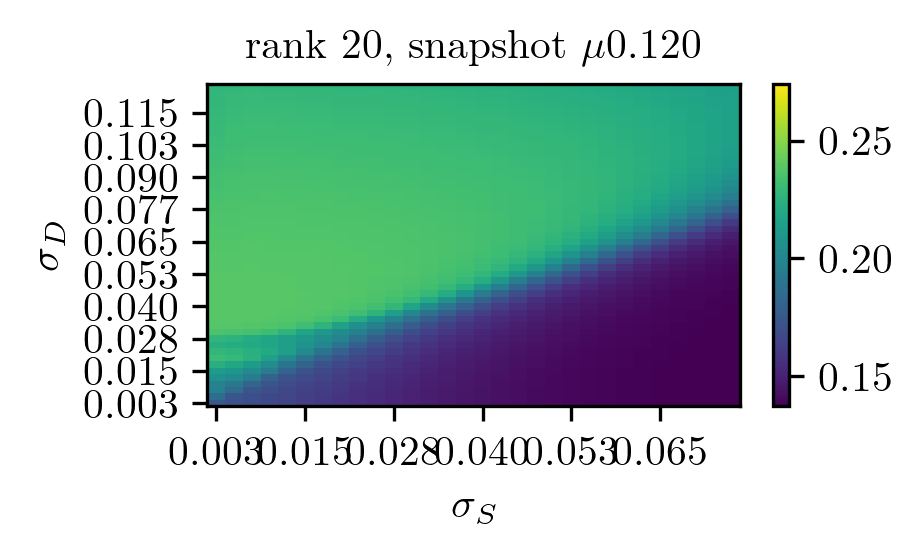

0.0025000000000000005 0.07500000000000001


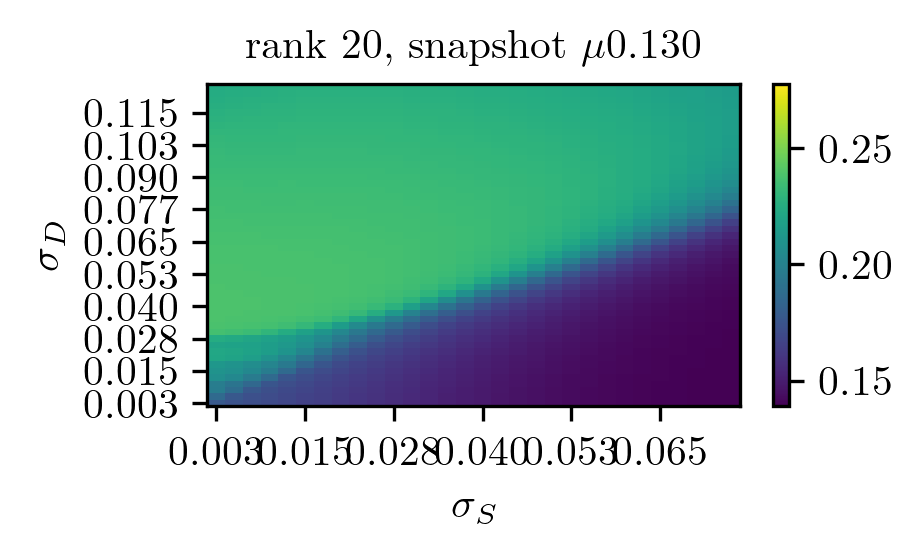

0.0025000000000000005 0.07500000000000001


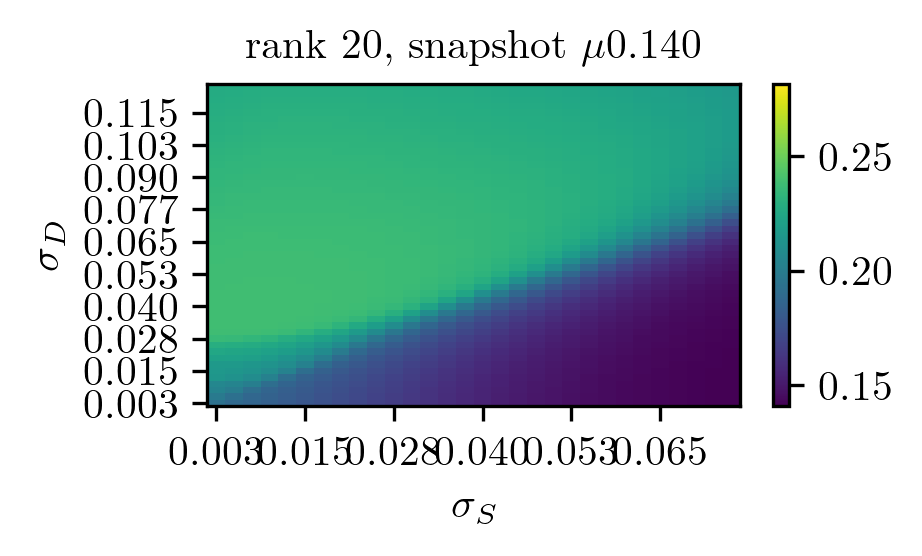

0.0025000000000000005 0.07500000000000001


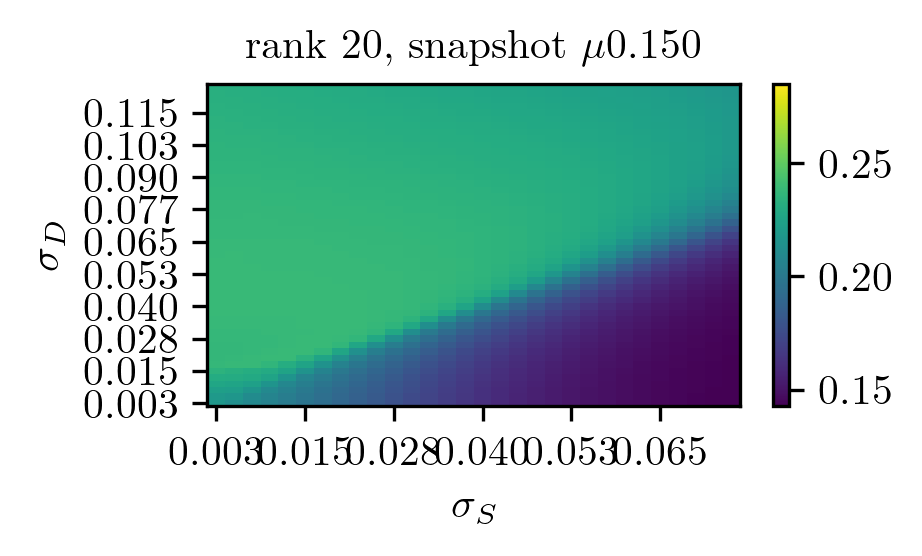

0.0025000000000000005 0.07500000000000001


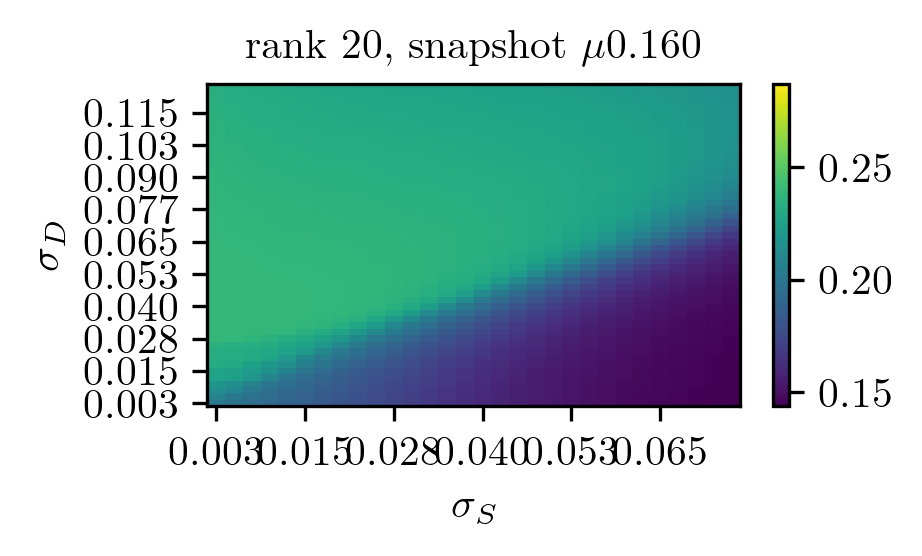

0.0025000000000000005 0.07500000000000001


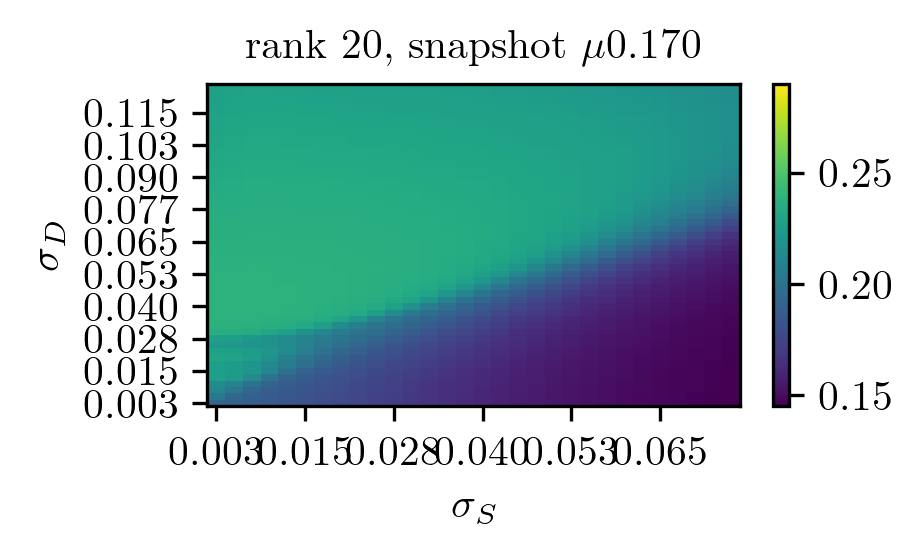

0.0025000000000000005 0.07500000000000001


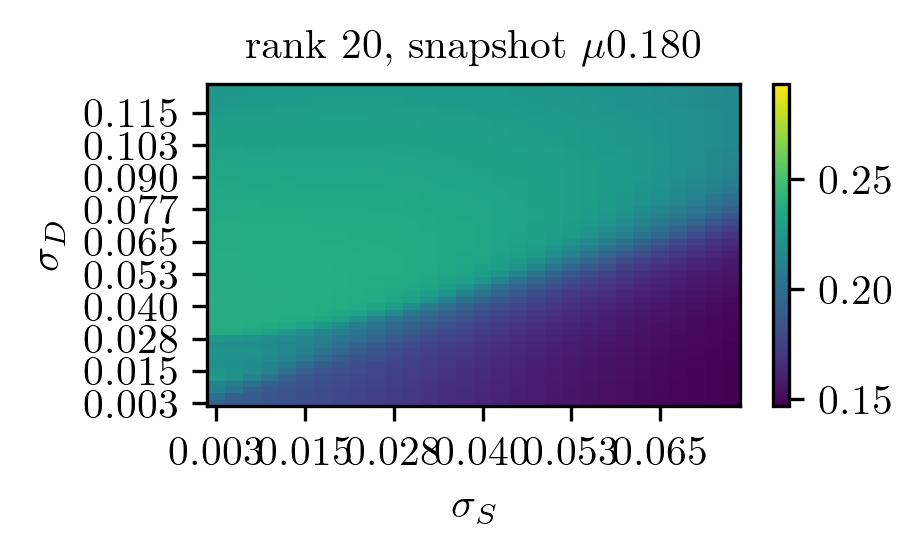

0.0025000000000000005 0.07500000000000001


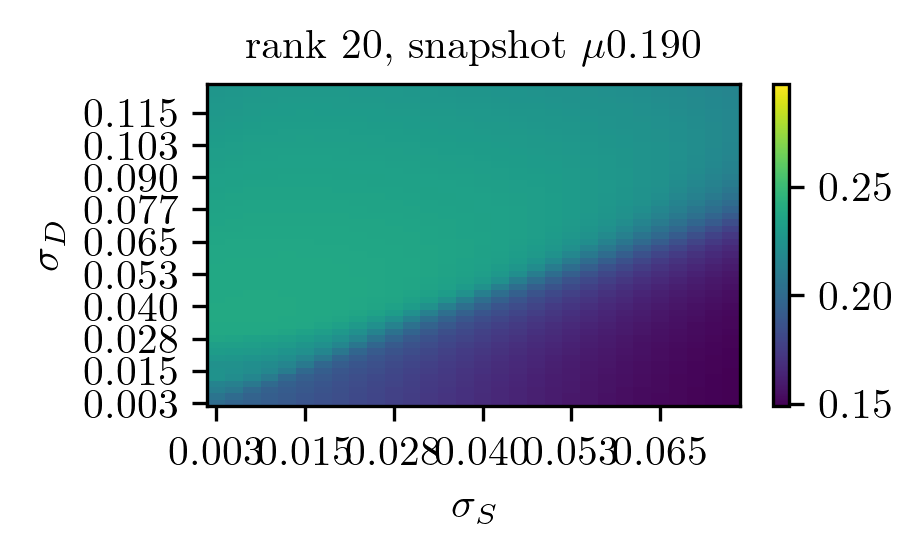

0.0016666666666666668 0.05


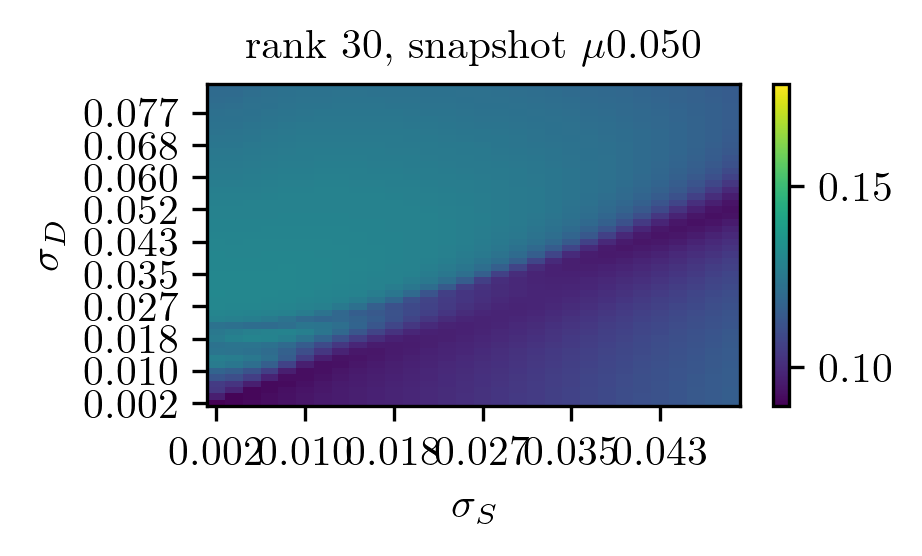

0.0016666666666666668 0.05


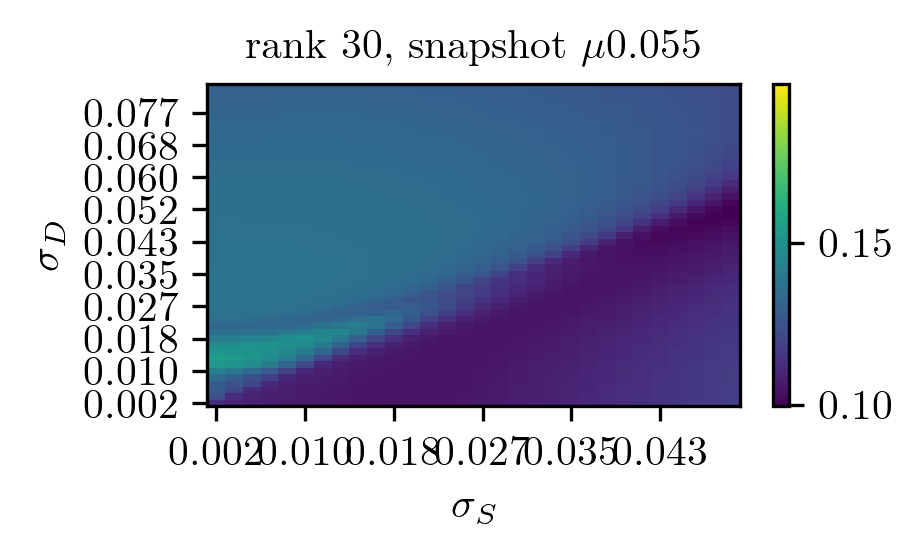

0.0016666666666666668 0.05


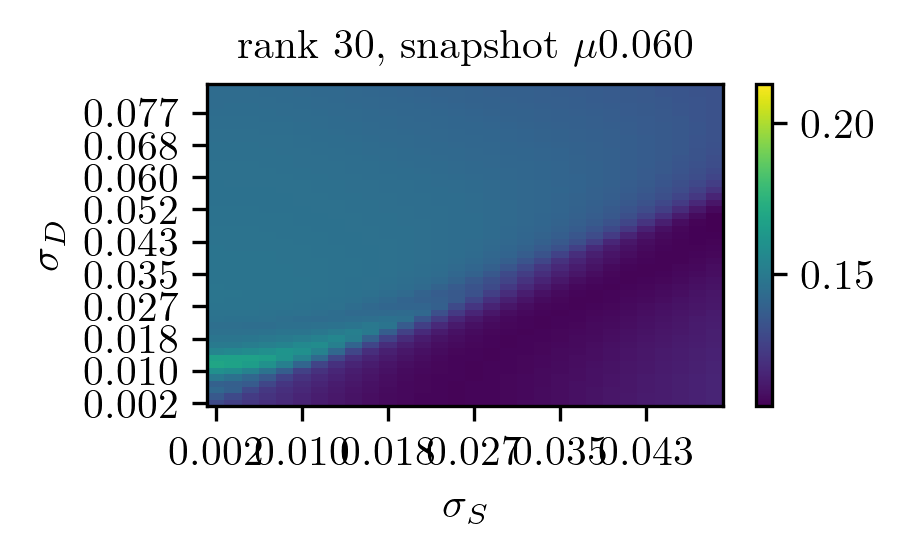

0.0016666666666666668 0.05


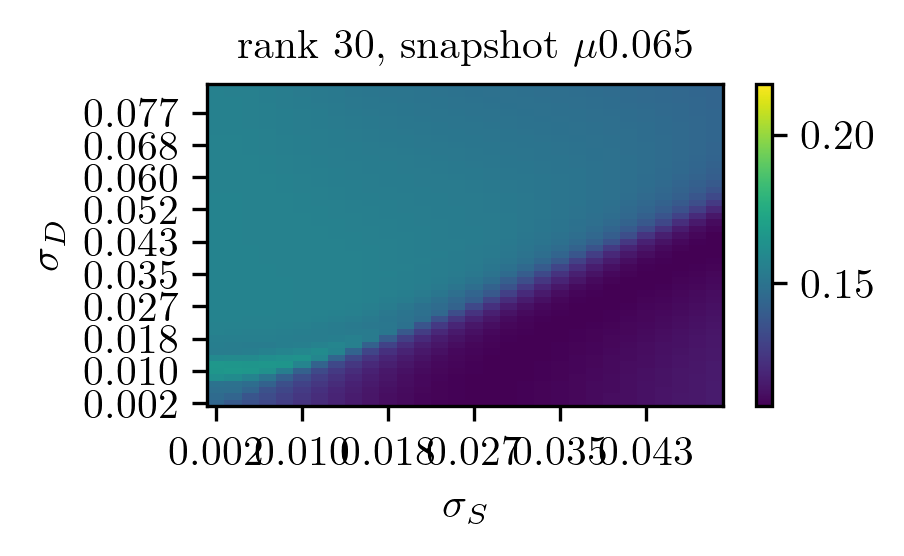

0.0016666666666666668 0.05


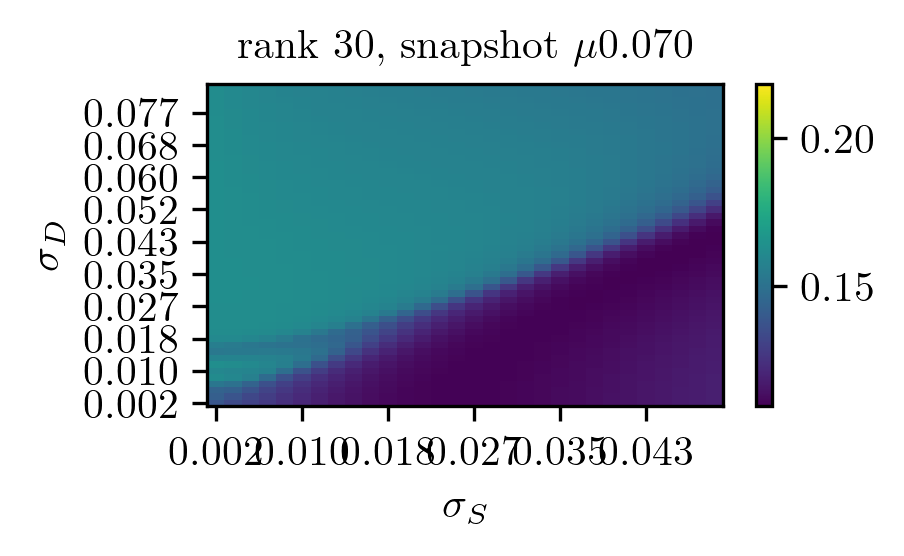

0.0016666666666666668 0.05


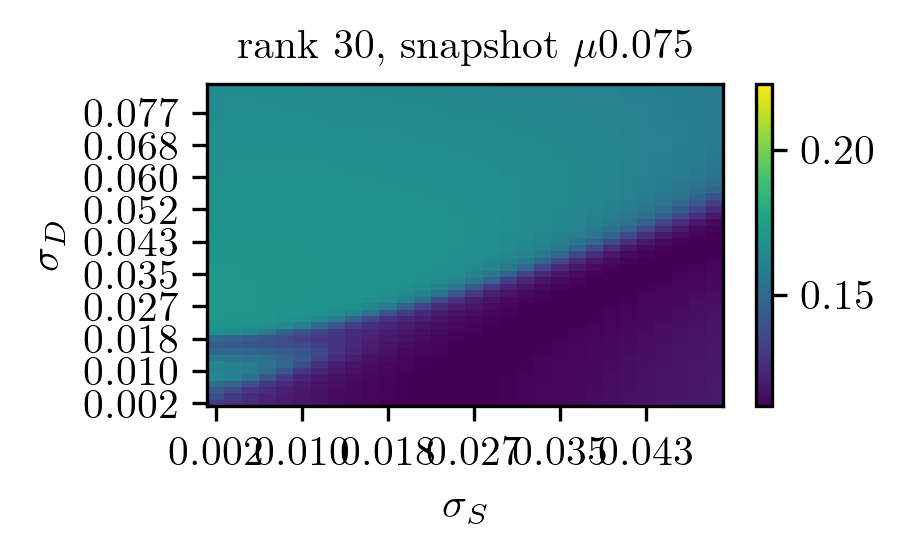

0.0016666666666666668 0.05


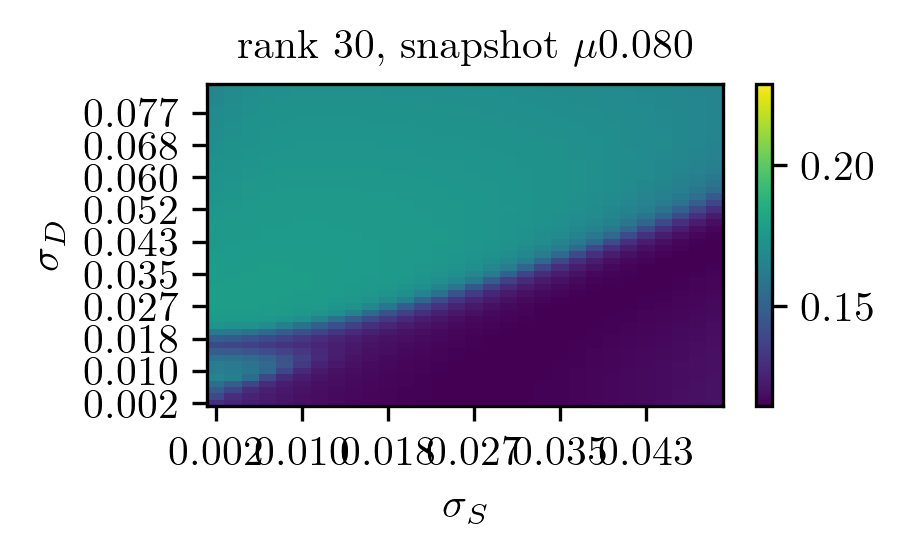

0.0016666666666666668 0.05


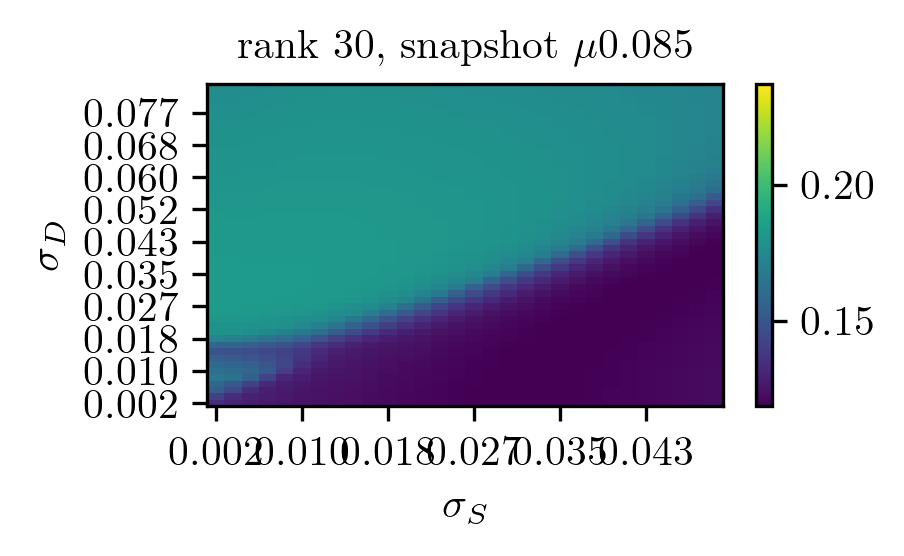

0.0016666666666666668 0.05


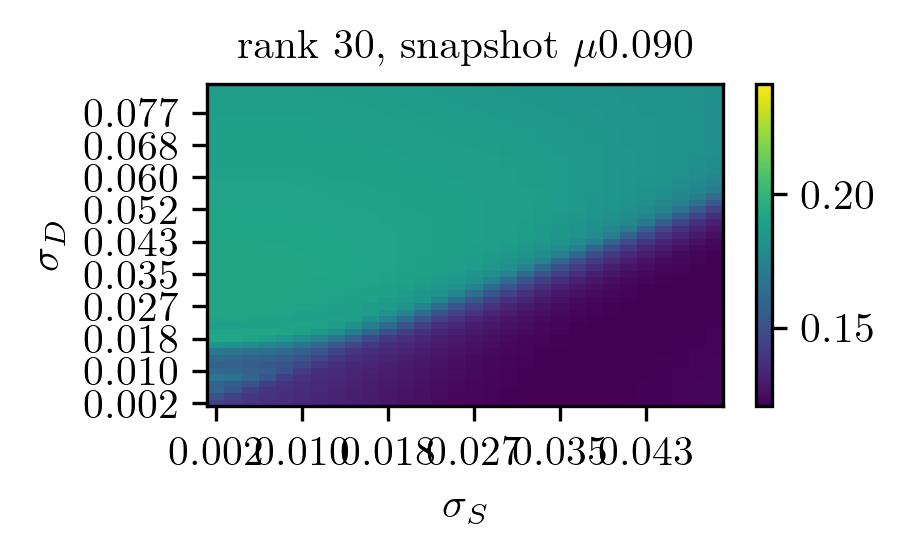

0.0016666666666666668 0.05


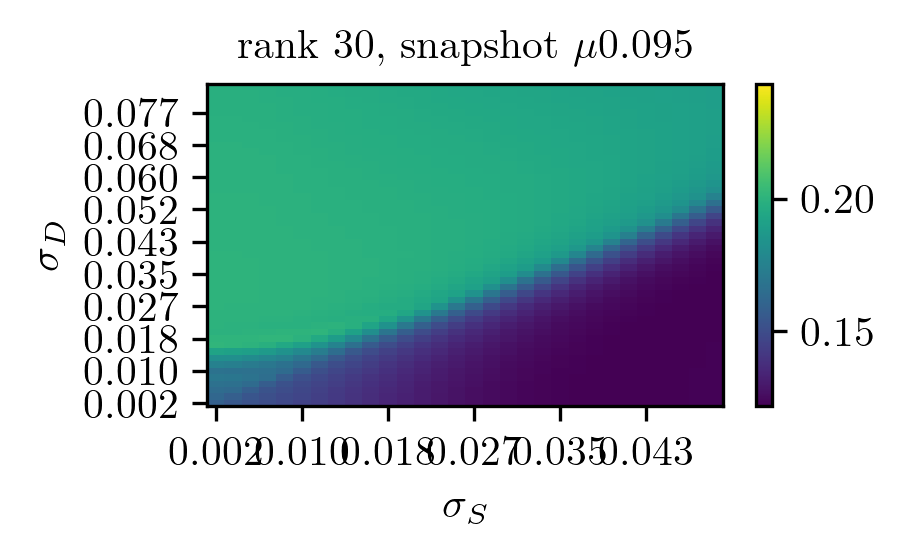

0.001 0.03


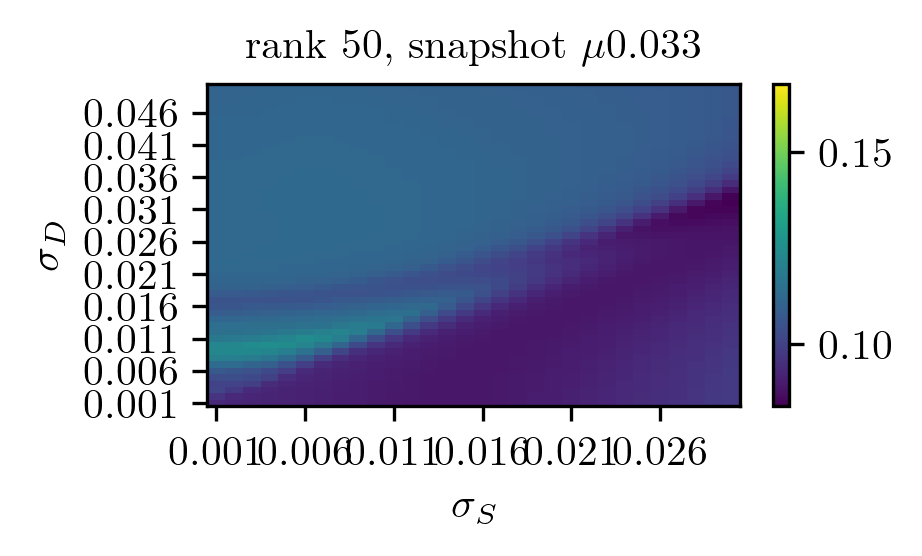

0.001 0.03


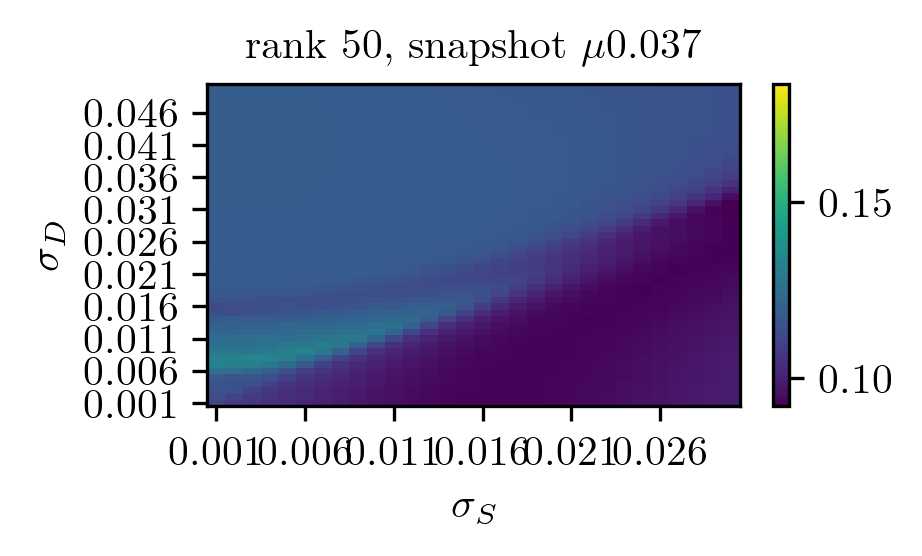

0.001 0.03


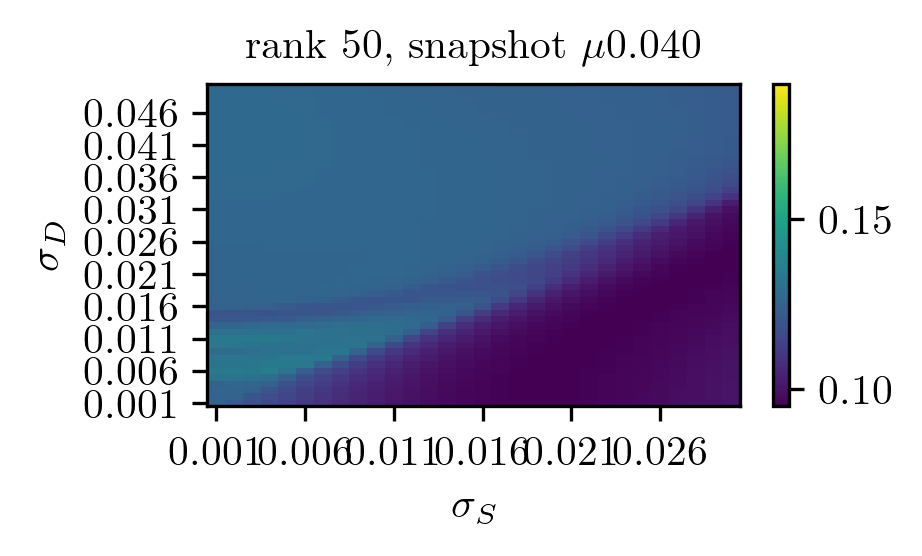

0.001 0.03


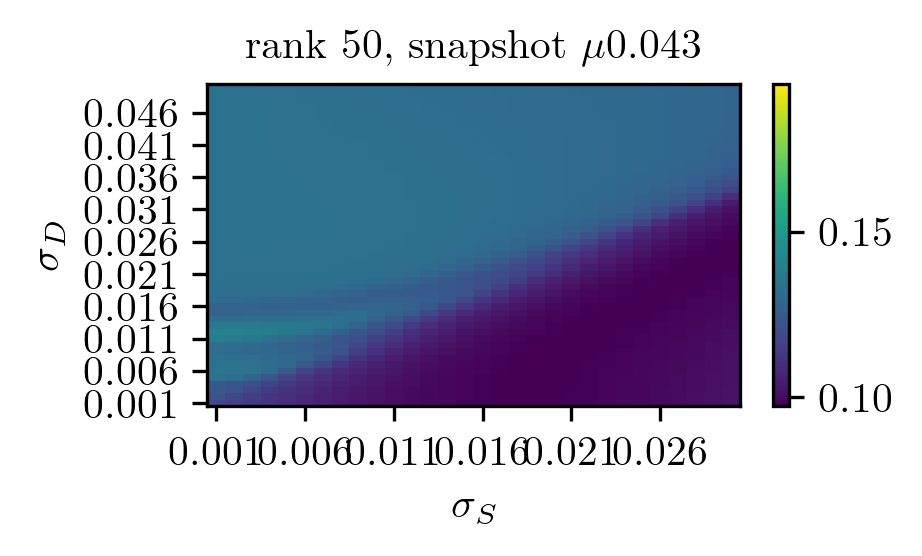

0.001 0.03


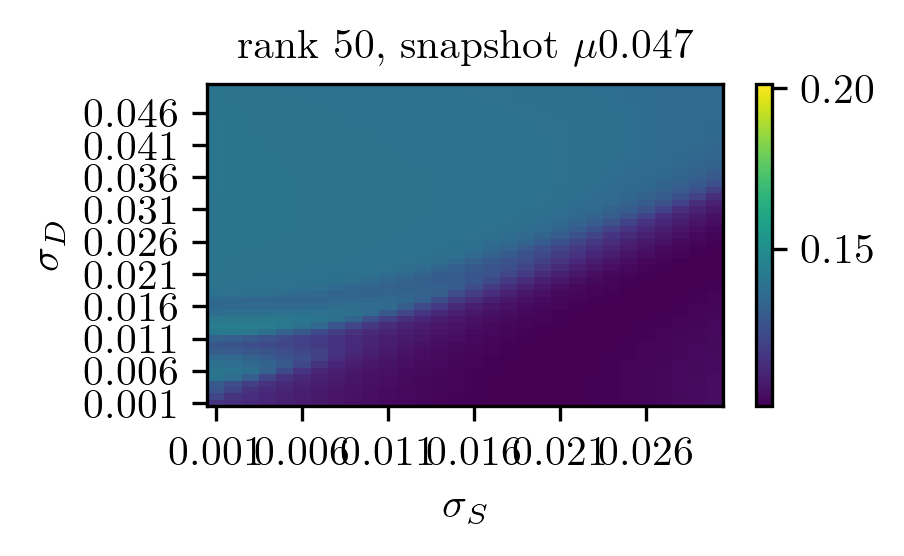

0.001 0.03


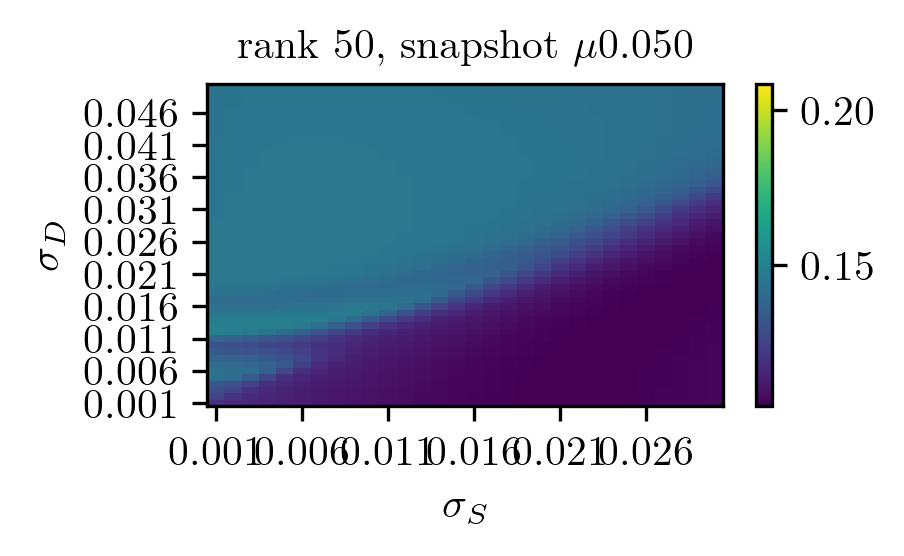

0.001 0.03


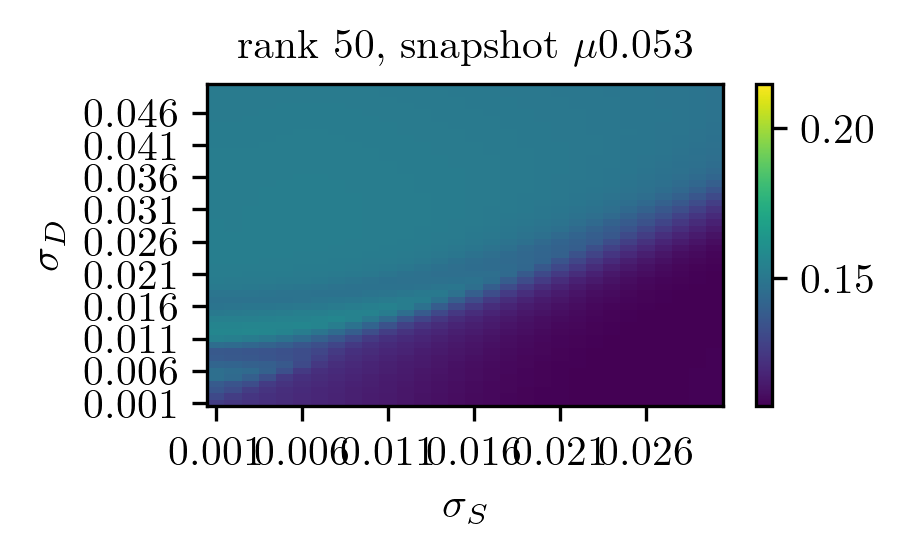

0.001 0.03


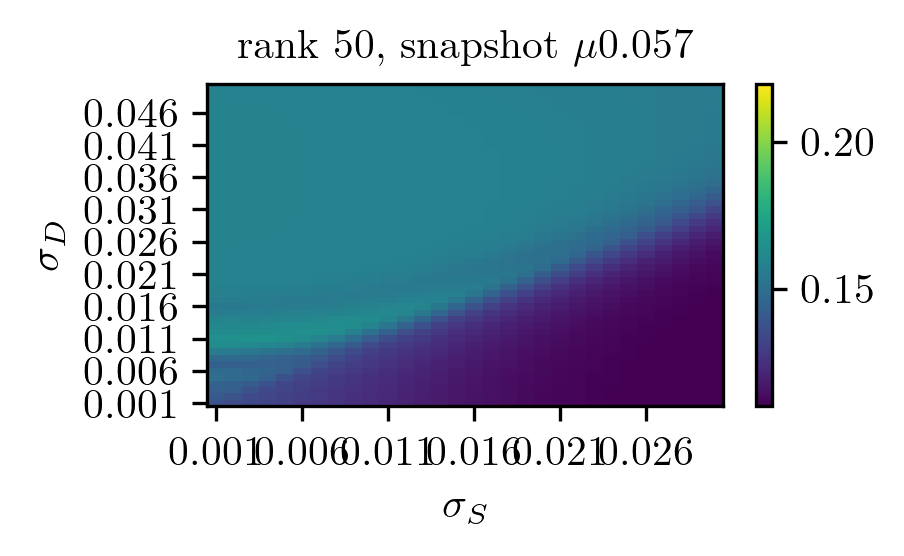

0.001 0.03


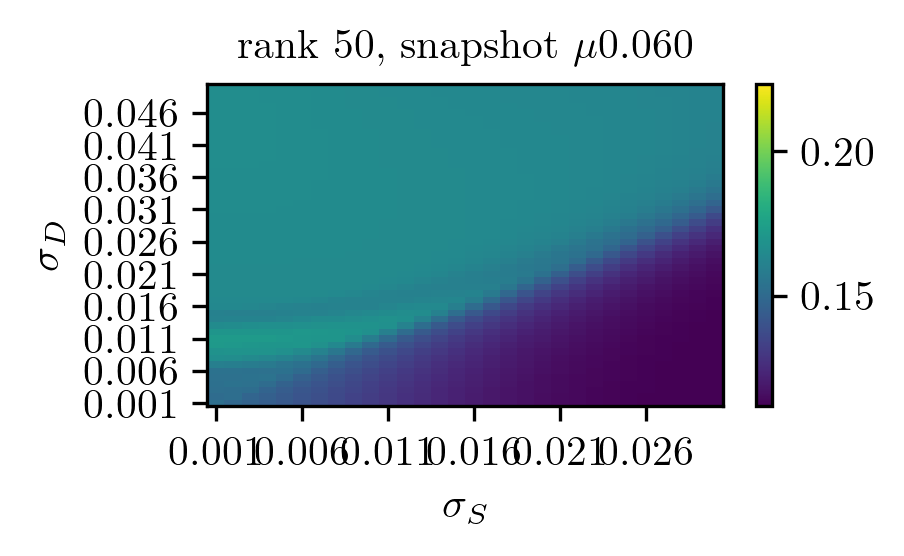

0.001 0.03


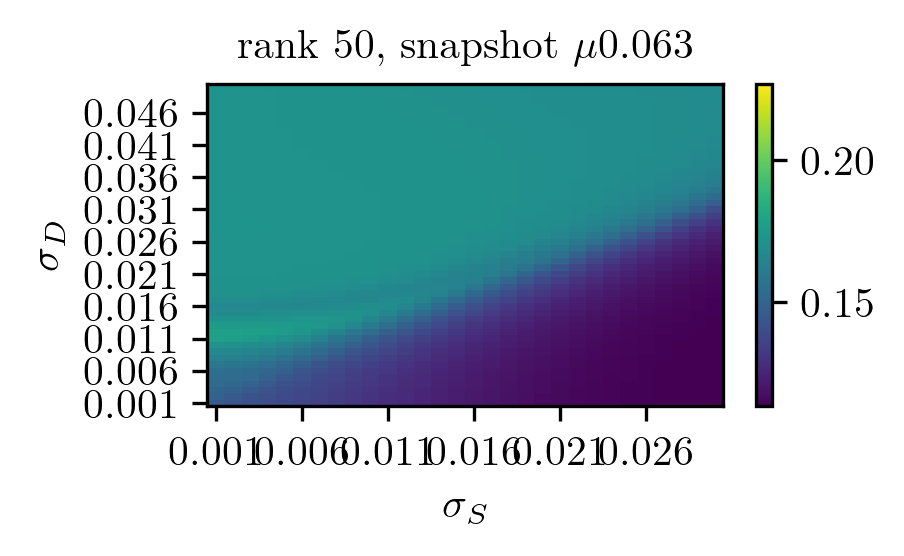

0.0005 0.015


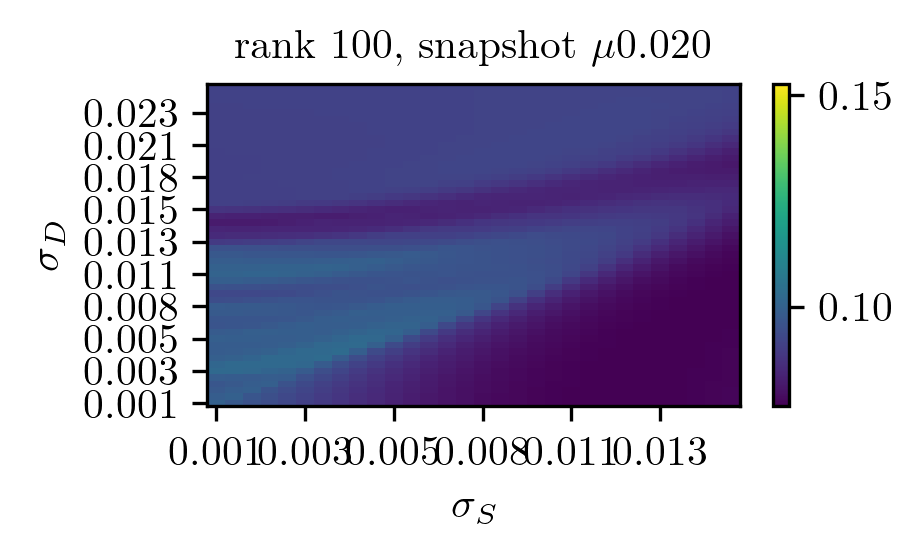

0.0005 0.015


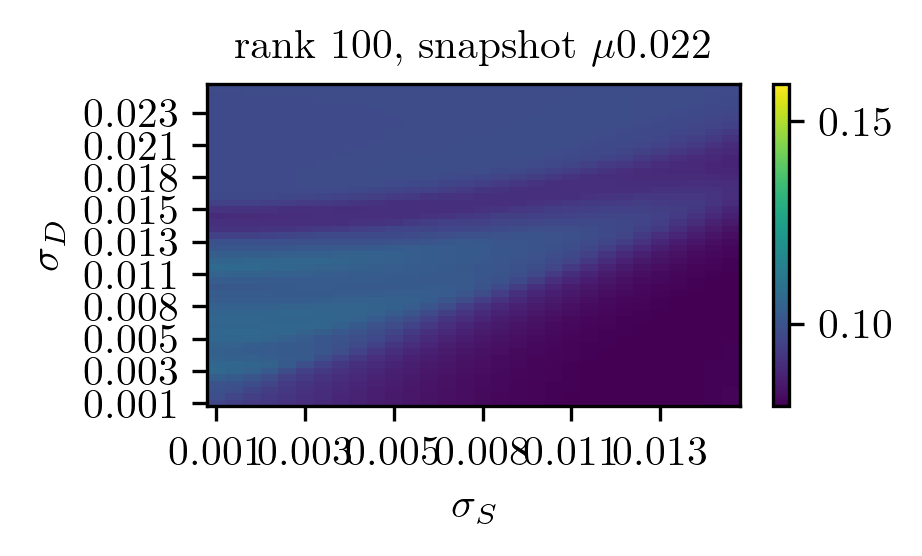

0.0005 0.015


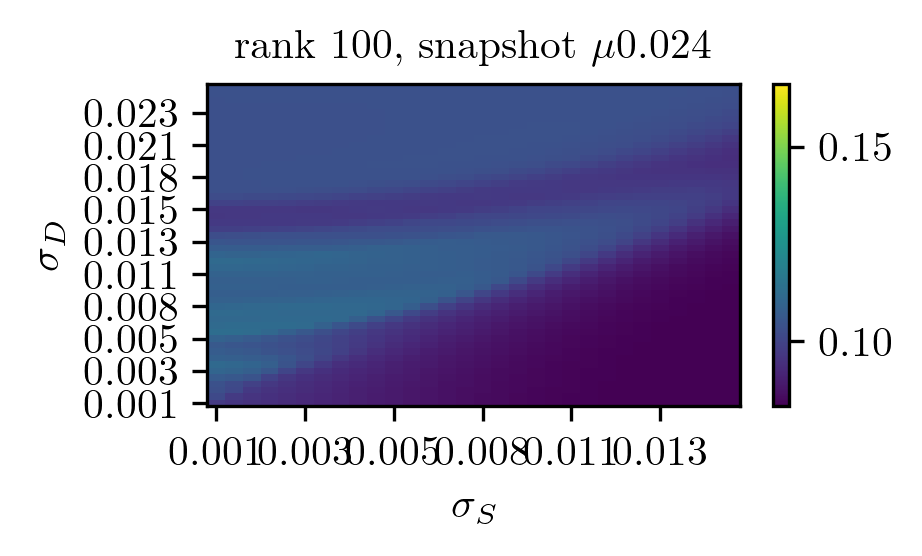

0.0005 0.015


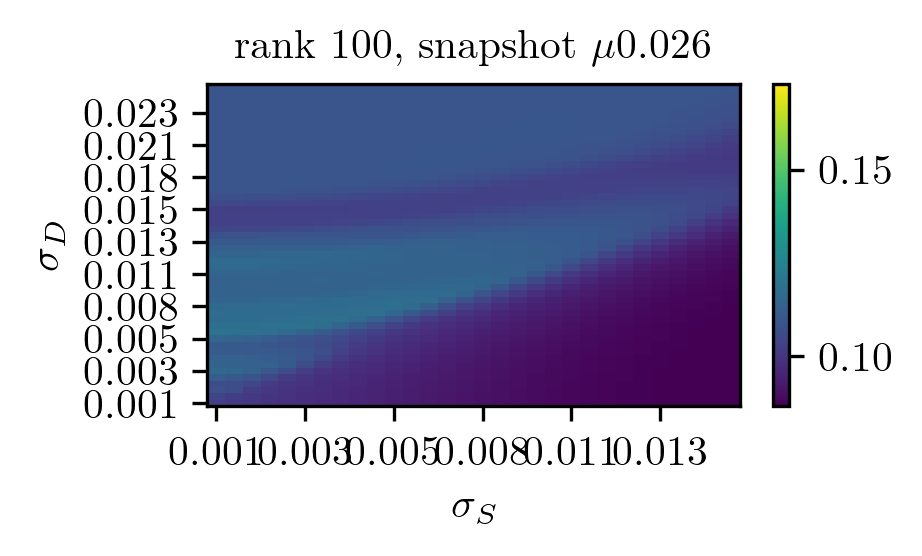

0.0005 0.015


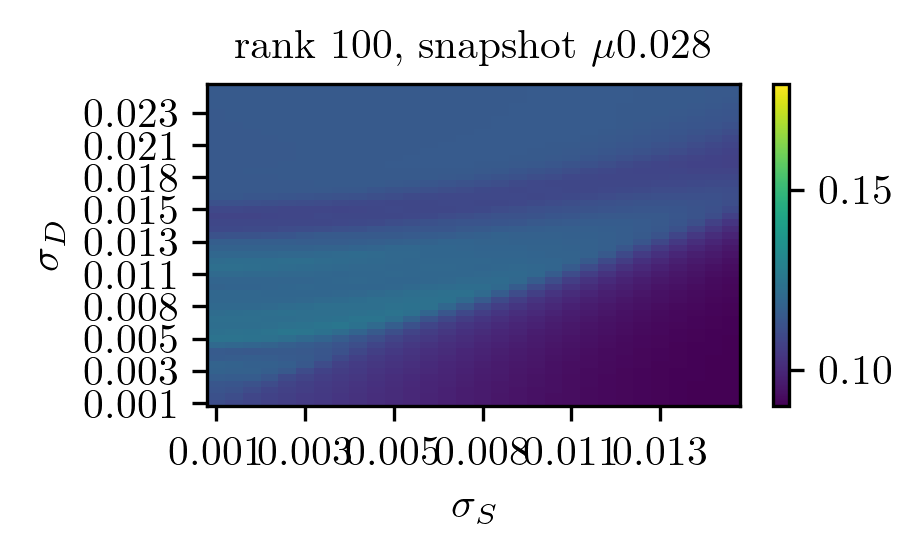

0.0005 0.015


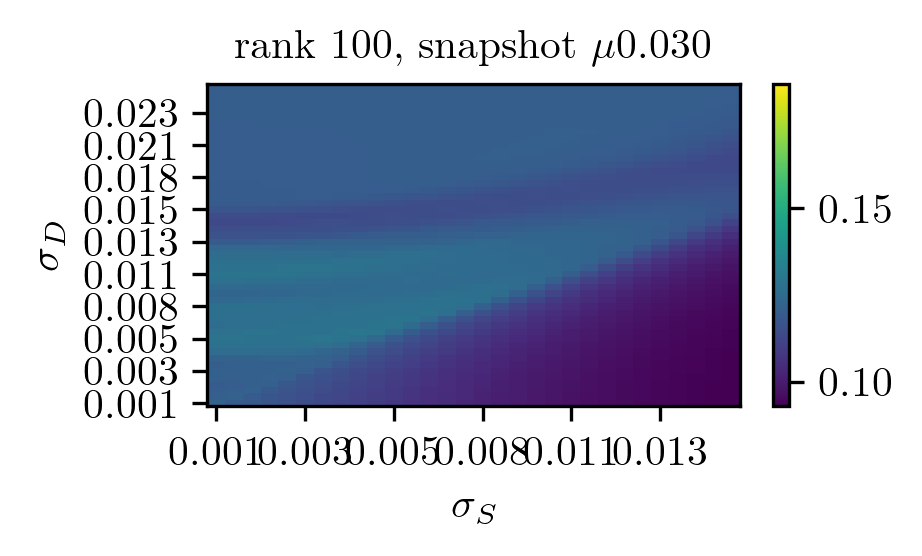

0.0005 0.015


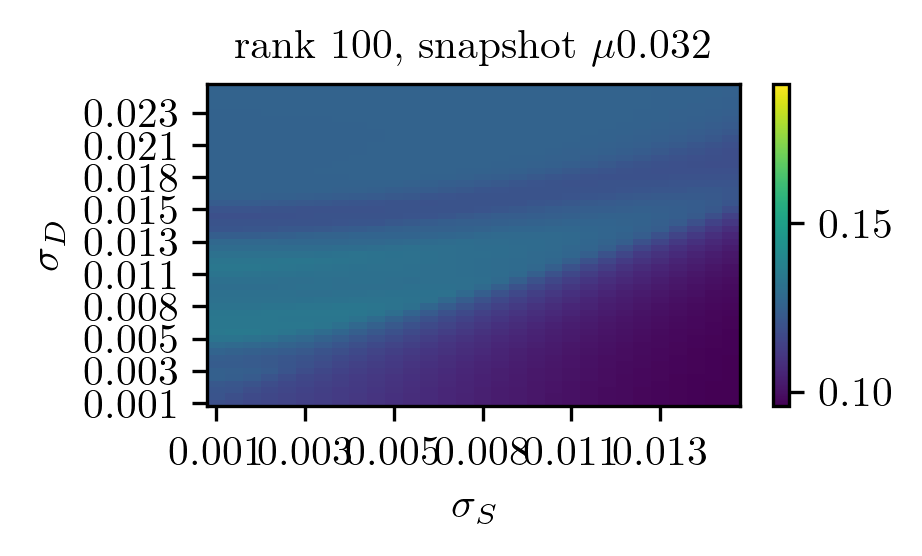

0.0005 0.015


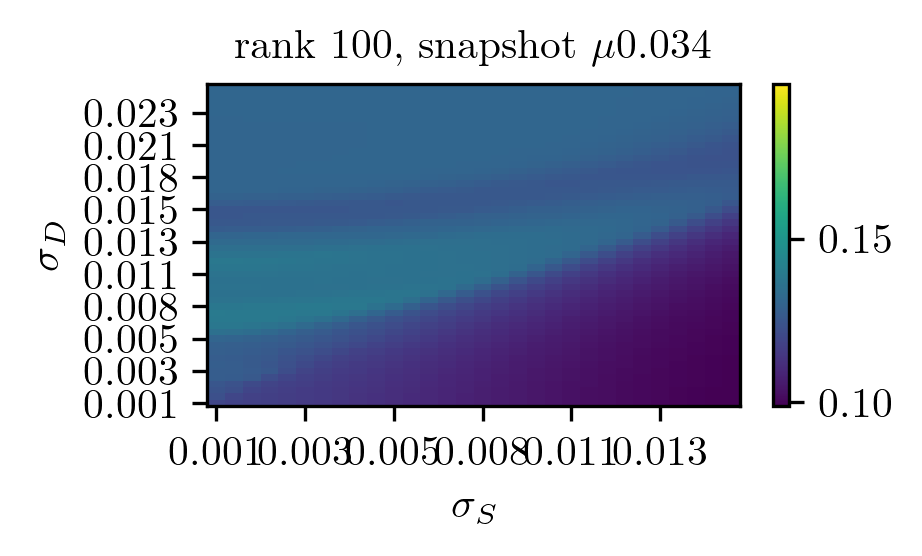

0.0005 0.015


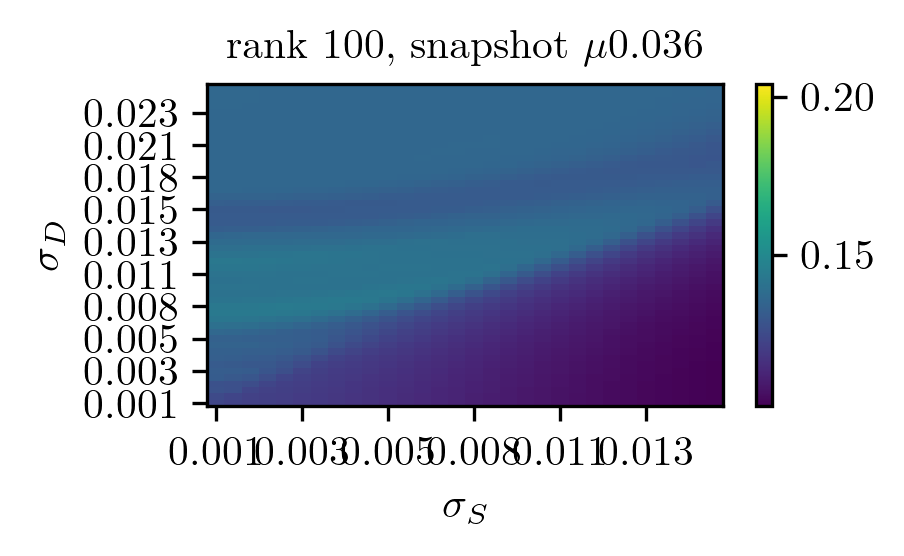

0.0005 0.015


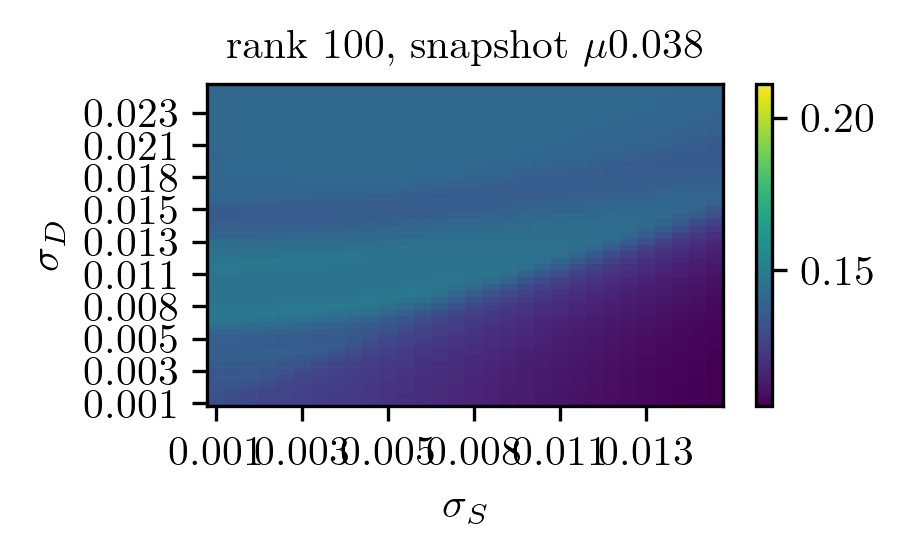

In [8]:
for i, rank in enumerate([10, 20, 30, 50, 100]):
    case["rank"] = rank
    case["n_train"] = rank
    case["n_test"] = 10
    sigma_opt = 1 / (rank * 2)

    sSs = np.linspace(sigma_opt*0.1, sigma_opt*3, nsS)
    sDs = np.linspace(sigma_opt*0.1, sigma_opt*5, nsD)
    xx, yy = np.meshgrid(sSs, sDs, indexing="ij")

    for j, mu in enumerate(mu_test):
        print(sigma_opt*0.1, sigma_opt*3)
        for r, sgm_S in enumerate(sSs):
            case["sigma"] = sgm_S
            mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
            if RAND:
                mu_test, X_test, X_test_s = make_rand_data_rw(np.min(mu_train), np.max(mu_train), n_samples=10, **case)
            else:
                mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=10, **case)
            my_sROM = train_ROM_rw(mu_train, X_train_s)
    
            for s, sgm_D in enumerate(sDs):
                #if (r-7<s) and (s<r+7):
                    case["sigmaD"] = [sgm_D]
                    
                    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, np.array([mu]), **case)
                    e = L2_error_rw(X_test_sROMs[0], X_test[j], axis=0)
    
                    sigma_S[i, j, r, s] = sgm_S
                    sigma_D[i, j, r, s] = sgm_D
                    ranks[i, j, r, s] = rank
                    mus[i, j, r, s] = mu[0]
                    errors[i, j, r, s] = e
        #plt.imshow(errors[i, j])
        fig, ax = plt.subplots()
        mesh = ax.pcolormesh(xx, yy, errors[i, j], shading=None, cmap='viridis', vmin=np.min(errors[i, j]), vmax=np.min(errors[i, j])*2)
        ax.set_xticks(sSs[::5])
        ax.set_yticks(sDs[::5])
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        ax.set_xlabel(r"$\sigma_S$")
        ax.set_ylabel(r"$\sigma_D$")
        
        plt.title("rank "+str(rank)+r", snapshot $\mu$"+"{:.3f}".format(mu[0]))
        cbar = plt.colorbar(mesh, ax=ax)
        plt.show()


In [9]:
asd

NameError: name 'asd' is not defined

In [ ]:
plt.imshow(errors[i, j])

In [ ]:
plt.imshow(errors[0, 0])
plt.show()
plt.imshow(sigma_S[0, 0])
plt.show()
plt.imshow(sigma_D[0, 0])
plt.show()

In [ ]:
asd

In [ ]:
sigma_S = np.array(sigma_S).reshape(5, 10)
sigma_D = np.array(sigma_D).reshape(5, 10)
ranks = np.array(ranks).reshape(5, 10)
mus = np.array(mus).reshape(5, 10)

In [ ]:
for i in range(5):
    plt.plot(sigma_S[i], sigma_D[i], "bo")

In [ ]:
sigma_S = np.array(sigma_S).reshape(5, 10)
sigma_D = np.array(sigma_D).reshape(5, 10)
ranks = np.array(ranks).reshape(5, 10)
mus = np.array(mus).reshape(5, 10)

for i in range(5):
    plt.plot(sigma_D[i])

In [ ]:
asd

In [ ]:
print("parameter optimization for a given rank")
sigma, c = optimize_hyperparameters(case)

print("generate data")
mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
mu_val, X_val, X_val_s = make_data_rw(mu_train[0], mu_train[-1], n_samples=case["n_val"], **case)

print("build ROM")
my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

Fig3(x, mu_train, X_train, X_train_s)
#plt.savefig(pth + "Fig3.pdf")

print("predict")
X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

Fig4(x, 5, mu_train, mu_test, X_train, X_train_s, X_test, X_test_ROM, X_test_sROM)
#plt.savefig(pth + "Fig4.pdf")
Fig5(x, X_test, X_test_s, X_test_ROM, X_test_sROM, X_test_sROMs)
#plt.savefig(pth + "Fig5.pdf")

print("model performance validation")
X_val_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)
eROM = L2_error_rw(X_val_ROM, X_val)
esROM = L2_error_rw(X_val_sROM, X_val)
esROMs = L2_error_rw(X_val_sROMs, X_val)
imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
imp2 = 100 - np.mean(esROMs2) / np.mean(eROM) * 100
print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter1, imp1))
print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter2, imp2))
Fig6(mu_val, eROM, esROM, esROMs, esROMs2)
#plt.savefig(pth + "Fig6.pdf")

print("brute force hyperparams")
#Fig7(eROM_mat, esROM_mat, esROMs_mat, c_all, sgms)

print("optimize for SINGLE snapshot and investigate convergence of RL")
sgima, c = optimize_hyperparameters_single()